## Complete Fine-tuning Pipeline for T5-FLAN Model

In [2]:
# Install necessary libraries for fine-tuning
!pip install transformers accelerate evaluate datasets --quiet

In [4]:
import re
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments, Seq2SeqTrainer,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)
import torch
import gc

# Helper function to trim text (re-defined for self-containment)
MAX_RESUME_CHARS = 1200
MAX_JD_CHARS = 1200

def trim(text, n):
    text = '' if pd.isna(text) else str(text)
    return text[:n]

### 1. Load Data and Initial Preprocessing

In [5]:
# 1. Load the Excel file and rename columns
excel_file_path = '/content/cv_jd_gap_analysis_master.xlsx'
try:
    df = pd.read_excel(excel_file_path)
    df.rename(columns={
        'Resume_Text': 'resume_text',
        'JD_Text': 'job_text',
        'Job_Title': 'job_title',
        'Gap_Analysis': 'gap_analysis',
    }, inplace=True)
    print(f"Successfully loaded data from {excel_file_path}. Shape: {df.shape}")
    print("Renamed Columns:", df.columns.tolist())
except FileNotFoundError:
    print(f"Error: The file '{excel_file_path}' was not found. Please ensure it's uploaded to Colab.")
    raise
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")
    raise

Successfully loaded data from /content/cv_jd_gap_analysis_master.xlsx. Shape: (2384, 10)
Renamed Columns: ['ID', 'resume_text', 'job_title', 'job_text', 'gap_analysis', 'Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5']


### 2. Build Input Text and Target Questions

In [6]:
# 2. Build input_text combining gap analysis, job title, and trimmed resume/JD
df['input_text'] = (
    "generate 5 interview questions from this gap analysis.\n"
    "Role: " + df['job_title'].fillna('') + "\n"
    "Gap Analysis: " + df['gap_analysis'].fillna('') + "\n"
    "Resume: " + df['resume_text'].apply(lambda t: trim(t, MAX_RESUME_CHARS)) + "\n"
    "Job Description: " + df['job_text'].apply(lambda t: trim(t, MAX_JD_CHARS))
)

# 3. Build target_questions by combining and numbering question columns
question_columns = ['Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5']
for col in question_columns:
    df[col] = df[col].fillna('').astype(str).str.strip()

df['target_questions'] = df.apply(
    lambda r: "\n".join(f"{i+1}) {r[c]}" for i, c in enumerate(question_columns)),
    axis=1
)

print("Sample of input_text and target_questions:")
display(df[['input_text', 'target_questions']].head())

# Sanity check target length
target_word_lens = df['target_questions'].str.split().str.len()
print("\nTarget word-count percentiles:\n", target_word_lens.describe())

Sample of input_text and target_questions:


,input_text,target_questions
0,generate 5 interview questions from this gap a...,1) I don't see comprehensive knowledge of comm...
1,generate 5 interview questions from this gap a...,1) I don't see extensive knowledge of classica...
2,generate 5 interview questions from this gap a...,1) One area we'd want to probe: minimum 4-6 ye...
3,generate 5 interview questions from this gap a...,1) Can you tell me about any exposure to exper...
4,generate 5 interview questions from this gap a...,1) I don't see proficiency with project manage...



Target word-count percentiles:
 count    2384.000000
mean      156.469379
std         9.979916
min       126.000000
25%       150.000000
50%       156.000000
75%       163.000000
max       203.000000
Name: target_questions, dtype: float64


### 3. Stratified Dataset Split

In [7]:
# 4. Stratified split to ensure job_title representation in train and validation
train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['job_title']
)

hf_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df, preserve_index=False),
})

print("\nHugging Face DatasetDict structure:")
print(hf_dataset)


Hugging Face DatasetDict structure:
DatasetDict({
    train: Dataset({
        features: ['ID', 'resume_text', 'job_title', 'job_text', 'gap_analysis', 'Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5', 'input_text', 'target_questions'],
        num_rows: 2145
    })
    validation: Dataset({
        features: ['ID', 'resume_text', 'job_title', 'job_text', 'gap_analysis', 'Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5', 'input_text', 'target_questions'],
        num_rows: 239
    })
})


### 4. Tokenization

In [8]:
# 5. Load Tokenizer and Tokenize Dataset
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Check actual token length before picking max_input_length
sample_input_lens = [len(tokenizer(t)['input_ids']) for t in df['input_text'].sample(200, random_state=0)]
sample_target_lens = [len(tokenizer(t)['input_ids']) for t in df['target_questions'].sample(200, random_state=0)]
print("input_text token length p95:", sorted(sample_input_lens)[int(len(sample_input_lens)*0.95)])
print("target token length p95:", sorted(sample_target_lens)[int(len(sample_target_lens)*0.95)])

# Set max lengths based on analysis, adjusted for T5 (which has slightly higher token counts)
max_input_length = 640   # Adjusted from 512
max_target_length = 220  # Adjusted from 128

def preprocess_function(examples):
    model_inputs = tokenizer(examples['input_text'], max_length=max_input_length, truncation=True)
    labels = tokenizer(examples['target_questions'], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

columns_to_remove = list(hf_dataset['train'].features.keys())
tokenized_datasets = hf_dataset.map(preprocess_function, batched=True, remove_columns=columns_to_remove, load_from_cache_file=False)

print("\nSample of tokenized train dataset features:")
print(tokenized_datasets['train'][0])

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.54k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.42M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/2.20k [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (654 > 512). Running this sequence through the model will result in indexing errors


input_text token length p95: 713
target token length p95: 251


Map:   0%|          | 0/2145 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]


Sample of tokenized train dataset features:
{'input_ids': [3806, 305, 2772, 746, 45, 48, 6813, 1693, 5, 2158, 109, 10, 1592, 1121, 23516, 17476, 2776, 102, 10582, 10, 12296, 17763, 10, 3, 2, 357, 4704, 13, 2616, 15395, 21, 3, 31, 21417, 1121, 23516, 17476, 31, 2385, 2084, 26, 16, 8, 4258, 5, 25243, 7, 3, 87, 12296, 15, 7, 10, 10199, 31, 7, 1952, 16, 23516, 6, 23516, 2855, 6, 42, 1341, 1057, 117, 3226, 31, 7, 1952, 6241, 117, 7477, 1294, 4392, 28, 3472, 748, 1339, 379, 1036, 758, 1002, 6, 6076, 872, 1976, 7, 6, 8373, 53, 9019, 7, 6, 11, 18913, 889, 117, 7187, 464, 28, 2399, 1236, 11683, 379, 1566, 1612, 15257, 6, 481, 28, 534, 523, 6, 11, 20945, 481, 6241, 5, 2776, 102, 7, 3, 87, 933, 2084, 26, 10, 23545, 538, 2119, 5151, 42, 3344, 21, 6980, 17082, 1073, 117, 16366, 738, 1103, 16, 306, 496, 17082, 379, 27502, 6, 23898, 6, 6467, 5307, 32, 17685, 6, 554, 18, 10379, 83, 302, 6, 11, 7779, 302, 117, 15782, 29, 7, 17, 4094, 1705, 13, 3, 3138, 15869, 1950, 200, 2869, 6, 18231, 26, 8033, 6, 11

### 5. Clear GPU Memory, Load Model, and Freeze Encoder Layers

In [ ]:
# Clear stale GPU memory
for _name in ["model", "trainer"]:
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()
print("\n" + torch.cuda.memory_summary(abbreviated=True))

# Load the model
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Freeze the encoder layers
for param in model.encoder.parameters():
    param.requires_grad = False

print("Encoder layers frozen. Only decoder and classification head will be trained.")

# Inspect trainable parameters:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Percentage of trainable parameters: {100 * trainable_params / total_params:.2f}%")


|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|--------------------------------------------------------------

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Encoder layers frozen. Only decoder and classification head will be trained.
Total parameters: 247577856
Trainable parameters: 137949312
Percentage of trainable parameters: 55.72%


### 5c. Freezing Layers for Partial Fine-Tuning

To fine-tune only specific parts of the model (e.g., only the decoder), we can freeze the parameters of the layers we don't want to train. This saves computational resources and can act as a regularization technique.

For T5, a common strategy is to freeze the encoder and train only the decoder, which is responsible for generating the output sequence.

In [ ]:
# ---------------------------------------------------------
# 5c. Freeze the encoder layers of the T5 model
# ---------------------------------------------------------
from transformers import AutoModelForSeq2SeqLM
import torch # Required for inspecting parameters

# Define model_name here to ensure it's always available
model_name = "google/flan-t5-base"

# Reload the model to ensure it's a fresh instance and accessible here
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Freeze the encoder layers
for param in model.encoder.parameters():
    param.requires_grad = False

print("Encoder layers frozen. Only decoder and classification head will be trained.")

# You can also inspect trainable parameters:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")
print(f"Percentage of trainable parameters: {100 * trainable_params / total_params:.2f}%")

config.json:   0%|          | 0.00/1.40k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/990M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

Encoder layers frozen. Only decoder and classification head will be trained.
Total parameters: 247577856
Trainable parameters: 137949312
Percentage of trainable parameters: 55.72%


### 6. Define Training Arguments and Initialize Trainer

In [ ]:
# 6. Define Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_finetuned_frozen_encoder", # Separate output directory
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=2,       # Smaller batch size
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,       # To achieve effective batch size of 8
    gradient_checkpointing=True,         # Memory saving technique
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=15,
    predict_with_generate=True,
    fp16=False,                          # T5 is prone to NaN with fp16
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    logging_dir='./logs_frozen_encoder', # Separate logging directory
)

# 7. Initialize Data Collator and Trainer
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("DataCollator and Trainer initialized with frozen encoder.")

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


DataCollator and Trainer initialized with frozen encoder.


### 7. Start Fine-tuning

In [ ]:
# 8. Start Fine-tuning
print("\nStarting T5-FLAN fine-tuning with frozen encoder...")
trainer.train()

print("\nFine-tuning complete. Model and tokenizer saved to ./flan_t5_finetuned_frozen_encoder")

# Save the fine-tuned model and tokenizer
trainer.save_model("./flan_t5_finetuned_frozen_encoder")
tokenizer.save_pretrained("./flan_t5_finetuned_frozen_encoder")

# Evaluate the model
print("\nEvaluating the fine-tuned model on the validation set...")
results = trainer.evaluate()
print(results)


Starting T5-FLAN fine-tuning with frozen encoder...


Epoch,Training Loss,Validation Loss
1,1.736080,0.239379
2,0.991593,0.206373
3,0.813454,0.188280
4,0.696573,0.181181
5,0.625764,0.175493
6,0.571750,0.180640
7,0.526813,0.175195
8,0.494628,0.168609
9,0.465736,0.175241
10,0.444607,0.179830


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Fine-tuning complete. Model and tokenizer saved to ./flan_t5_finetuned_frozen_encoder


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating the fine-tuned model on the validation set...


Training Loss,Validation Loss,Epoch
0.428736,0.168609,11


{'eval_loss': 0.16860930621623993}


### 8. Inference Function

In [ ]:
# 9. Define Inference Function
def generate_questions(job_title, gap_analysis, resume_text, jd_text, tokenizer, model,
                        max_length=max_target_length, max_input_len=max_input_length):
    input_text = (
        "generate 5 interview questions from this gap analysis.\n"
        f"Role: {job_title}\n"
        f"Gap Analysis: {gap_analysis}\n"
        f"Resume: {trim(resume_text, MAX_RESUME_CHARS)}\n"
        f"Job Description: {trim(jd_text, MAX_JD_CHARS)}"
    )
    input_ids = tokenizer.encode(input_text, return_tensors='pt', truncation=True, max_length=max_input_len)
    if torch.cuda.is_available():
        input_ids = input_ids.cuda()
        model.cuda()
    output_ids = model.generate(
        input_ids,
        max_length=max_length,
        num_beams=4,
        no_repeat_ngram_size=3,
    )
    raw = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Parse "1) ... 2) ... " back into a list
    parts = re.split(r'\n?\d\)\s*', raw)
    questions = [p.strip() for p in parts if p.strip()]
    return questions

### 9. Test the Fine-Tuned Model

In [ ]:
# Example data for inference
example_job_title = "Software Engineer"
example_gap_analysis = "Candidate lacks experience with distributed systems and cloud platforms (AWS, Azure, GCP), which are key requirements for the role. The resume highlights experience with Django and React, but the job requires a backend focus."
example_resume_text = """
EXPERIENCE
Software Engineer | Tech Solutions Inc. | Jan 2020 - Present
- Developed and maintained web applications using Python, Django, and React.
- Implemented RESTful APIs, improving data retrieval efficiency by 30%.
- Collaborated with cross-functional teams to define, design, and ship new features.
Machine Learning Intern | AI Innovations Lab | May 2019 - Aug 2019
- Researched and developed NLP models for sentiment analysis.
- Preprocessed large datasets (1M+ entries) and performed feature engineering.
EDUCATION
Master of Science in Computer Science | State University | 2019
Bachelor of Engineering in Computer Science | City College | 2017
SKILLS
Programming: Python, Java, JavaScript, C++
Frameworks: Django, React, Flask, Node.js
Databases: PostgreSQL, MySQL, MongoDB
Tools: Docker, Git, AWS
Languages: English (Native), Spanish (Fluent)
"""
example_jd_text = """
Job Title: Senior Software Engineer
Company: Global Dynamics
Location: Remote

Responsibilities:
- Lead the design, development, and deployment of scalable backend services.
- Mentor junior engineers and conduct code reviews.
- Work with product managers to translate requirements into technical specifications.
- Optimize application performance and ensure high availability.

Requirements:
- 5+ years of experience in software development, with a focus on backend.
- Strong proficiency in Python and cloud platforms (AWS, Azure, GCP).
- Experience with microservices architecture and distributed systems.
- Excellent communication and leadership skills.
- Bachelor's or Master's degree in Computer Science or related field.
"""

print("Generating questions based on the example data...")

generated_interview_questions = generate_questions(
    job_title=example_job_title,
    gap_analysis=example_gap_analysis,
    resume_text=example_resume_text,
    jd_text=example_jd_text,
    tokenizer=tokenizer,
    model=model
)

print("\n--- Generated Interview Questions ---")
for i, q in enumerate(generated_interview_questions):
    print(f"{i+1}) {q}")

Generating questions based on the example data...

--- Generated Interview Questions ---
1) This role requires minimum 5+ years of experience in software development, with a focus on backend focus. What's the closest experience you've had to this, even if it wasn't the main focus of a job?
2) Can you tell me about any exposure to experience with distributed systems and cloud platforms (AWS, Azure, GCP) and experience with microservices architecture and distributed systems, since it isn't clear from what's listed?
3) Your resume lists experience with Django and React on your resume — can you give a concrete, specific example of using this?
4) You open your resume by positioning yourself around "Experience Software Engineer | Tech Solutions Inc" — how does that connect to what this role actually needs day to day?
5) One of the core responsibilities here is "Lead end-to-end development processes for web and mobile applications, from initial research and concept development through final i

### 10. Another Example to Test the Fine-Tuned Model

In [ ]:
# Another example data for inference
example_job_title_2 = "Data Scientist"
example_gap_analysis_2 = "Candidate has strong theoretical knowledge in machine learning but lacks practical experience in deploying models to production and A/B testing. Resume focuses heavily on academic projects."
example_resume_text_2 = """
EXPERIENCE
Research Assistant | University of Data Science | Jan 2021 - Present
- Conducted research on novel deep learning architectures for natural language processing.
- Implemented models using TensorFlow and PyTorch, achieving state-of-the-art results on benchmark datasets.
- Published 3 papers in peer-reviewed conferences.
EDUCATION
Ph.D. in Computer Science | University of Data Science | 2023 (Expected)
Master of Science in Data Science | Data Institute | 2020
SKILLS
Programming: Python (NumPy, Pandas, Scikit-learn, TensorFlow, PyTorch), R
Tools: Jupyter, Git, Docker
Concepts: Machine Learning, Deep Learning, NLP, Computer Vision, Statistical Modeling
"""
example_jd_text_2 = """
Job Title: Senior Data Scientist
Company: DataDriven Solutions
Location: New York

Responsibilities:
- Develop, deploy, and maintain machine learning models in a production environment.
- Design and execute A/B tests to evaluate model performance and impact.
- Collaborate with engineering and product teams to integrate models into existing systems.
- Mentor junior data scientists.

Requirements:
- 3+ years of industry experience in data science, with a focus on model deployment.
- Strong programming skills in Python.
- Experience with cloud platforms (AWS, Azure, GCP) and MLOps practices.
- Solid understanding of statistical inference and experimental design (A/B testing).
- Ph.D. or Master's degree in a quantitative field.
"""

print("Generating questions based on the second example data...")

generated_interview_questions_2 = generate_questions(
    job_title=example_job_title_2,
    gap_analysis=example_gap_analysis_2,
    resume_text=example_resume_text_2,
    jd_text=example_jd_text_2,
    tokenizer=tokenizer,
    model=model
)

print("\n--- Generated Interview Questions (Example 2) ---")
for i, q in enumerate(generated_interview_questions_2):
    print(f"{i+1}) {q}")

Generating questions based on the second example data...

--- Generated Interview Questions (Example 2) ---
1) This role requires minimum 3+ years of industry experience in data science, with a focus on model deployment and A/B testing. What's the closest experience you've had to this, even if it wasn't the main focus of a job?
2) I don't see experience with cloud platforms (AWS, Azure, GCP) and MLOps practices evidenced in your resume — what relevant experience can you share here?
3) You mention 'Microsoft Visual Studio 2012'. How proficient are you really, on a scale from 'comfortable' to 'expert', and what's your evidence?
4) Tell me about a time your experience with professional certifications such as PMP, SCI, or similar certifications preferred directly impacted a result you're proud of.
5) You open your resume by positioning yourself around "Research Assistant | University of Data Science | Jan 2021" — how does that connect to what this role actually needs day to day


### 11. Save and Zip the Fine-Tuned Model

In [ ]:
import zipfile
import os

# Define the directory where you want to save the model and tokenizer
output_dir = "./flan_t5_finetuned_frozen_encoder_local_save"

# Save the model
trainer.save_model(output_dir)

# Save the tokenizer
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to: {output_dir}")

# Define the name for the output zip file
zip_file_name = './flan_t5_finetuned_frozen_encoder_local_save.zip'

print(f"Zipping folder: {output_dir} into {zip_file_name}...")

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(output_dir):
        for file in files:
            # Construct the full path to the file
            file_path = os.path.join(root, file)
            # Add the file to the zip archive, preserving its relative path within the folder
            zipf.write(file_path, os.path.relpath(file_path, output_dir))

print(f"Successfully created {zip_file_name}")
print("You can now download this single zip file from the Colab file browser.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./flan_t5_finetuned_frozen_encoder_local_save
Zipping folder: ./flan_t5_finetuned_frozen_encoder_local_save into ./flan_t5_finetuned_frozen_encoder_local_save.zip...
Successfully created ./flan_t5_finetuned_frozen_encoder_local_save.zip
You can now download this single zip file from the Colab file browser.


In [ ]:
# 5. Load Tokenizer and Tokenize Dataset
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)

# Check actual token length before picking max_input_length
sample_input_lens = [len(tokenizer(t)['input_ids']) for t in df['input_text'].sample(200, random_state=0)]
sample_target_lens = [len(tokenizer(t)['input_ids']) for t in df['target_questions'].sample(200, random_state=0)]
print("input_text token length p95:", sorted(sample_input_lens)[int(len(sample_input_lens)*0.95)])
print("target token length p95:", sorted(sample_target_lens)[int(len(sample_target_lens)*0.95)])

# Set max lengths based on analysis, adjusted for T5 (which has slightly higher token counts)
max_input_length = 640   # Adjusted from 512
max_target_length = 220  # Adjusted from 128

def preprocess_function(examples):
    model_inputs = tokenizer(examples['input_text'], max_length=max_input_length, truncation=True)
    labels = tokenizer(examples['target_questions'], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

columns_to_remove = list(hf_dataset['train'].features.keys())
tokenized_datasets = hf_dataset.map(preprocess_function, batched=True, remove_columns=columns_to_remove, load_from_cache_file=False)

print("\nSample of tokenized train dataset features:")
print(tokenized_datasets['train'][0])

In [9]:
import evaluate
import numpy as np
import gc
import torch
import os # Import os module to check for directory existence
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments, Seq2SeqTrainer,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)

# --- Start of re-establishing dependencies for a fresh session ---
# IMPORTANT: Before running this cell:
# 1. Ensure you have uploaded your fine-tuned model directory to Colab.
#    Update 'fine_tuned_model_path' below to point to your model's location.
# 2. Run the data loading, preprocessing, and tokenization cells (
#    a077cedf, b909082e, a99ee539, bac62a53 from your notebook)
#    to define 'tokenized_datasets'. Alternatively, load a pre-tokenized dataset.

# 1. Clear stale GPU memory (good practice for fresh runs)
for _name in ["model", "tokenizer", "trainer", "training_args", "data_collator"]:
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(abbreviated=True))

# 2. Define the path to your uploaded fine-tuned model
#    Corrected path based on previous save operation in cell 6f0be3b7.
fine_tuned_model_path = "./flan_t5_finetuned_frozen_encoder_local_save"
zip_file_path = "./flan_t5_finetuned_frozen_encoder_local_save.zip"

# Check if the model directory exists, if not, try to unzip the archive
if not os.path.isdir(fine_tuned_model_path):
    print(f"\nModel directory '{fine_tuned_model_path}' not found. Checking for zip archive...")
    if os.path.exists(zip_file_path):
        print(f"Found zip archive '{zip_file_path}'. Unzipping...")
        # Create the directory before unzipping into it
        os.makedirs(fine_tuned_model_path, exist_ok=True)
        !unzip -o {zip_file_path} -d {fine_tuned_model_path} # -o for overwrite if already exists
        print("Unzipping complete. Re-checking model directory.")
        if not os.path.isdir(fine_tuned_model_path):
            print("ERROR: Model directory still not found after unzipping.")
            raise FileNotFoundError(f"Model directory not found at {fine_tuned_model_path} even after unzipping.")
    else:
        print(f"\nERROR: Model directory '{fine_tuned_model_path}' not found!")
        print("Please ensure you have uploaded and unzipped your fine-tuned model folder.")
        print("If you uploaded the '.zip' file, you need to unzip it first (e.g., `!unzip ./flan_t5_finetuned_frozen_encoder_local_save.zip`).")
        print("If your model is in a different location, please update the `fine_tuned_model_path` variable.")
        raise FileNotFoundError(f"Model directory not found at {fine_tuned_model_path}")

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------

In [10]:
# 3. Load the model and tokenizer
print(f"Loading model and tokenizer from: {fine_tuned_model_path}")
tokenizer = AutoTokenizer.from_pretrained(fine_tuned_model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(fine_tuned_model_path)

# If your model was fine-tuned with a frozen encoder, you might want to re-freeze it here
# if the saved model state does not automatically reflect this (e.g., if you only save adapter weights).
for param in model.encoder.parameters():
  param.requires_grad = False
print("Encoder layers frozen (if applicable).")



Loading model and tokenizer from: ./flan_t5_finetuned_frozen_encoder_local_save


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Encoder layers frozen (if applicable).


In [11]:
# 4. Re-define Training Arguments (as they are not persistent across sessions)
#    These parameters should match your original training setup.
training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_finetuned_frozen_encoder", # This path is for trainer outputs, not loading.
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,
    gradient_checkpointing=True,
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=15,
    predict_with_generate=True,
    fp16=False, # T5 is prone to NaN with fp16
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    logging_dir='./logs_frozen_encoder',
)



[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [17]:
!pip install rouge_score --quiet

# 5. Re-initialize Data Collator
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)
# --- End of re-establishing dependencies ---

# Load metrics
rouge = evaluate.load("rouge")

# Define the compute_metrics function
def compute_metrics(eval_preds):
    predictions, labels = eval_preds

    # 'predictions' is already a NumPy array when passed from Seq2SeqTrainer.evaluate with predict_with_generate=True
    # Remove .cpu() as it's not a torch tensor
    predictions_np = predictions # Changed from predictions.cpu().numpy()

    # Sanitize predictions: Replace any invalid token IDs
    # Invalid IDs could be negative (e.g., -100 for labels), or outside vocabulary range.
    # The tokenizer.vocab_size is the upper limit for valid token IDs.
    predictions_np = np.where(predictions_np < 0, tokenizer.pad_token_id, predictions_np)
    predictions_np = np.where(predictions_np >= tokenizer.vocab_size, tokenizer.pad_token_id, predictions_np)

    # Ensure integer type, as OverflowError implies type conversion issue
    predictions_np = predictions_np.astype(int)

    # Decode predictions and labels back to text
    decoded_preds = tokenizer.batch_decode(predictions_np, skip_special_tokens=True)

    # Replace -100 in labels as they represent padding and cannot be decoded.
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)
    decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

    # ROUGE metric expects a list of references for each prediction.
    # For a single reference, wrap it in a list. Also, handle potential empty reference strings.
    decoded_labels_filtered = [[label] if label.strip() else [""] for label in decoded_labels]

    # Compute ROUGE scores
    result = rouge.compute(
        predictions=decoded_preds,
        references=decoded_labels_filtered,
        use_stemmer=True  # Use stemming for better matching
    )

    # Add a 'gen_len' metric to see the average length of generated sequences
    prediction_lens = [np.count_nonzero(pred != tokenizer.pad_token_id) for pred in predictions_np]
    result["gen_len"] = np.mean(prediction_lens)

    # Round the results for cleaner display
    return {k: round(v, 4) for k, v in result.items()}

# Check if tokenized_datasets is defined, otherwise provide a warning.
if 'tokenized_datasets' not in globals():
    print("\nWARNING: 'tokenized_datasets' is not defined. Please run the data preparation cells first!\n")
    # Assign dummy empty datasets to allow the trainer to be initialized for code validation,
    # but actual train/eval operations will fail until real data is provided.
    tokenized_datasets = {'train': [], 'validation': []}

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Trainer re-initialized with compute_metrics function.")
print("To see the new ROUGE metrics, ensure 'tokenized_datasets' is correctly populated, then run `trainer.train()` and `trainer.evaluate()` again.")

Trainer re-initialized with compute_metrics function.
To see the new ROUGE metrics, ensure 'tokenized_datasets' is correctly populated, then run `trainer.train()` and `trainer.evaluate()` again.


In [18]:
print("\nEvaluating the fine-tuned model on the validation set to get metrics...")
results = trainer.evaluate(max_new_tokens=max_target_length)
print(results)


Evaluating the fine-tuned model on the validation set to get metrics...


[transformers] Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=220) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/

Training Loss,Validation Loss,Epoch,Rouge1,Rouge2,Rougel,Rougelsum,Gen Len
No log,0.168609,0,0.638900,0.459900,0.482400,0.482100,215.037700


{'eval_loss': 0.16860930621623993, 'eval_rouge1': 0.6389, 'eval_rouge2': 0.4599, 'eval_rougeL': 0.4824, 'eval_rougeLsum': 0.4821, 'eval_gen_len': 215.0377}


In [ ]:
# Install necessary libraries if not already installed
!pip install PyPDF2 transformers torch --quiet

import re
import pandas as pd
import PyPDF2
from google.colab import files
import io
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch

print("Please provide the following details to generate interview questions:")

# Get user input for the job title and gap analysis directly
user_job_title = input("Enter Job Title: ")
user_gap_analysis = input("Enter Gap Analysis: ")

# Function to extract text from a PDF file
def extract_text_from_pdf(pdf_file):
    reader = PyPDF2.PdfReader(pdf_file)
    text = ""
    for page_num in range(len(reader.pages)):
        page = reader.pages[page_num]
        text += page.extract_text() or ""
    return text

# Upload and process Resume PDF
print("\nPlease upload your Resume PDF file:")
uploaded_resume = files.upload()
if not uploaded_resume:
    print("No resume file uploaded. Exiting.")
    user_resume_text = ""
else:
    resume_file_name = next(iter(uploaded_resume))
    resume_pdf_file = io.BytesIO(uploaded_resume[resume_file_name])
    user_resume_text = extract_text_from_pdf(resume_pdf_file)
    print(f"Successfully extracted text from {resume_file_name}.")

# Upload and process Job Description PDF
print("\nPlease upload your Job Description PDF file:")
uploaded_jd = files.upload()
if not uploaded_jd:
    print("No job description file uploaded. Exiting.")
    user_jd_text = ""
else:
    jd_file_name = next(iter(uploaded_jd))
    jd_pdf_file = io.BytesIO(uploaded_jd[jd_file_name])
    user_jd_text = extract_text_from_pdf(jd_pdf_file)
    print(f"Successfully extracted text from {jd_file_name}.")


print("\nGenerating questions based on your input and uploaded PDFs...")

# Define the trim function and max lengths for self-containment
MAX_RESUME_CHARS = 1200
MAX_JD_CHARS = 1200
max_input_length = 640
max_target_length = 220

def trim(text, n):
    text = '' if pd.isna(text) else str(text)
    return text[:n]

# Load the fine-tuned model and tokenizer for self-containment
# Ensure this path matches where your fine-tuned model was saved.
model_path = "./flan_t5_finetuned_frozen_encoder" # Or "./flan_t5_finetuned_local_save" if that's the latest
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# Define the generate_questions function for self-containment
def generate_questions(job_title, gap_analysis, resume_text, jd_text, tokenizer, model,
                        max_length=max_target_length, max_input_len=max_input_length):
    input_text = (
        "generate 5 interview questions from this gap analysis.\n"
        f"Role: {job_title}\n"
        f"Gap Analysis: {gap_analysis}\n"
        f"Resume: {trim(resume_text, MAX_RESUME_CHARS)}\n"
        f"Job Description: {trim(jd_text, MAX_JD_CHARS)}"
    )
    input_ids = tokenizer.encode(input_text, return_tensors='pt', truncation=True, max_length=max_input_len)
    if torch.cuda.is_available():
        input_ids = input_ids.cuda()
        model.cuda()
    output_ids = model.generate(
        input_ids,
        max_length=max_length,
        num_beams=4,
        no_repeat_ngram_size=3,
    )
    raw = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # Parse "1) ... 2) ... " back into a list
    parts = re.split(r'\n?\d\)\s*', raw)
    questions = [p.strip() for p in parts if p.strip()]
    return questions

# Call the generate_questions function
generated_questions_from_input = generate_questions(
    job_title=user_job_title,
    gap_analysis=user_gap_analysis,
    resume_text=user_resume_text,
    jd_text=user_jd_text,
    tokenizer=tokenizer,
    model=model
)

print("\n--- Generated Interview Questions ---")
for i, q in enumerate(generated_questions_from_input):
    print(f"{i+1}) {q}")

In [ ]:
#Base model with all the param updates

In [ ]:
# Install necessary libraries for fine-tuning
!pip install transformers accelerate evaluate datasets --quiet

import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, Seq2SeqTrainingArguments, Seq2SeqTrainer, DataCollatorForSeq2Seq

# 1. Load the Excel file
excel_file_path = '/content/cv_jd_gap_analysis_master.xlsx' # Assuming it's in the default Colab content directory
try:
    df_finetune = pd.read_excel(excel_file_path)
    print(f"Successfully loaded data from {excel_file_path}. Shape: {df_finetune.shape}")
    print("Original Columns:", df_finetune.columns.tolist())
except FileNotFoundError:
    print(f"Error: The file '{excel_file_path}' was not found. Please ensure it's uploaded to Colab.")
    raise
except Exception as e:
    print(f"An error occurred while loading the Excel file: {e}")
    raise


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.7 MB/s eta 0:00:00
Successfully loaded data from /content/cv_jd_gap_analysis_master.xlsx. Shape: (2384, 10)
Original Columns: ['ID', 'Resume_Text', 'Job_Title', 'JD_Text', 'Gap_Analysis', 'Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5']


In [ ]:
# 2. Preprocess the DataFrame: Rename columns and create target
# User's keys from AefRsyCr7YMW output: ID, Resume_Text, Job_Title, JD_Text, Gap_Analysis, Question_1, Question_2, Question_3, Question_4, Question_5

# Correctly rename existing columns to the standardized format expected later in the code
df_finetune.rename(columns={'Resume_Text': 'resume_text', 'JD_Text': 'job_text'}, inplace=True)
# Also rename Job_Title if it's meant to be job_title (lowercase) for consistency, though not directly used in the error trace
df_finetune.rename(columns={'Job_Title': 'job_title'}, inplace=True)

# Add an explicit check for an empty DataFrame early
if df_finetune.empty:
    print("Warning: 'df_finetune' is empty. No questions will be generated and downstream steps may be affected.")
    # Create empty columns to prevent KeyErrors later
    df_finetune['resume_text'] = pd.Series(dtype=str)
    df_finetune['job_text'] = pd.Series(dtype=str)
    df_finetune['target_questions'] = pd.Series(dtype=str)
    df_finetune['input_text'] = pd.Series(dtype=str)
else:
    # Combine questions into a single target string
    # Correctly use the question column names from the Excel file (Question_1, Question_2, etc.)
    question_columns = ['Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5']

    # Ensure all *correct* question columns exist and are string type before combining
    for col in question_columns:
        if col not in df_finetune.columns:
            print(f"Error: Expected column '{col}' not found in Excel file. Please check Excel column names.")
            # As a fallback, add an empty column to prevent further errors
            df_finetune[col] = ''
        df_finetune[col] = df_finetune[col].fillna('').astype(str)

    # Create 'target_questions' by explicitly concatenating strings for each row
    # This avoids potential issues with .apply() returning unexpected types
    combined_questions = []
    for index, row in df_finetune[question_columns].iterrows():
        combined_q = ' '.join(row.values.astype(str))
        combined_questions.append(combined_q)

    df_finetune['target_questions'] = pd.Series(combined_questions, index=df_finetune.index)

    # Clean up target questions: replace multiple spaces with single space, remove leading/trailing spaces
    df_finetune['target_questions'] = df_finetune['target_questions'].str.replace(r'\s+', ' ', regex=True).str.strip()

    # Create 'input_text' for the T5 model
    # Format: "generate gap analysis questions: [RESUME_TEXT] [JOB_DESCRIPTION]"
    df_finetune['input_text'] = "generate gap analysis questions: " + df_finetune['resume_text'].fillna('') + " " + df_finetune['job_text'].fillna('')

    print("\nSample of prepared data for fine-tuning:")
    display(df_finetune[['ID', 'resume_text', 'job_text', 'target_questions', 'input_text']].head())
    print(f"Total rows after cleaning: {len(df_finetune)}")


Sample of prepared data for fine-tuning:


,ID,resume_text,job_text,target_questions,input_text
0,3547447,MORTGAGE BANKING FORECLOSURE SPECIALI...,Commercial Banking Relationship Manager\n-----...,I don't see comprehensive knowledge of commerc...,generate gap analysis questions: MORT...
1,10001727,SOUS CHEF Work Experience ...,Culinary Chef de Cuisine\n--------------------...,I don't see extensive knowledge of classical a...,generate gap analysis questions: SOUS...
2,10005171,MEDIA ACTIVITIES SPECIALIST Sum...,Social Media Marketing Manager\n--------------...,One area we'd want to probe: minimum 4-6 years...,generate gap analysis questions: MEDI...
3,10030015,ENGINEERING LAB TECHNICIAN Care...,Structural Engineering Project Manager\n------...,Can you tell me about any exposure to experien...,generate gap analysis questions: ENGI...
4,10041713,SR. ESTIMATOR-BAS CONSTRUCTION SALES ...,Construction Project Manager\n----------------...,I don't see proficiency with project managemen...,generate gap analysis questions: SR. ...


Total rows after cleaning: 2384


In [ ]:
import pandas as pd

# Save the df_finetune DataFrame to a CSV file
output_csv_path = '/content/df_finetune.csv'
df_finetune.to_csv(output_csv_path, index=False)

print(f"DataFrame saved successfully to {output_csv_path}")
print("You can now download this file from the Colab file browser.")

NameError: name 'df_finetune' is not defined

In [ ]:

# 3. Split the dataset into train and validation
train_df, val_df = train_test_split(df_finetune, test_size=0.1, random_state=42)

# Convert to Hugging Face Dataset format
hf_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df, preserve_index=False)
})

print("\nHugging Face DatasetDict structure for fine-tuning:")
print(hf_dataset)
print("\nSample of train dataset features for fine-tuning:")
print(hf_dataset['train'][0])


Hugging Face DatasetDict structure for fine-tuning:
DatasetDict({
    train: Dataset({
        features: ['ID', 'resume_text', 'job_title', 'job_text', 'Gap_Analysis', 'Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5', 'target_questions', 'input_text'],
        num_rows: 2145
    })
    validation: Dataset({
        features: ['ID', 'resume_text', 'job_title', 'job_text', 'Gap_Analysis', 'Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5', 'target_questions', 'input_text'],
        num_rows: 239
    })
})

Sample of train dataset features for fine-tuning:
{'ID': 22488036, 'resume_text': "         MECHANICAL DESIGN ENGINEER INTERN       Summary    Over 2 years of combined professional and educational experience in 3D Modelling and Product Design 1 year of hands-on experience in FEA, Stress Analysis, Numerical Modelling and Static / Dynamic Analysis Certified in Product Design / Analysis, Engineering Mechanics and OCTG Researched in the fields of CFD 

In [ ]:

# 4. Load Tokenizer and Model
model_name = "google/flan-t5-base" # You can choose other T5 models like "t5-small", "t5-base", "t5-large"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Map:   0%|          | 0/2145 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]


Sample of tokenized train dataset features:
{'input_ids': [3806, 6813, 1693, 746, 10, 7934, 25000, 23936, 31864, 3, 23182, 9730, 3316, 3, 21342, 14151, 20698, 2035, 204, 203, 13, 3334, 771, 11, 3472, 351, 16, 220, 308, 8731, 53, 11, 6246, 1642, 209, 215, 13, 1780, 18, 106, 351, 16, 3, 6392, 188, 6, 16059, 10582, 6, 1174, 935, 1950, 8731, 53, 11, 472, 6049, 3, 87, 13967, 3113, 10582, 10178, 16, 6246, 1642, 3, 87, 10582, 6, 5623, 3, 27501, 9, 2532, 7, 11, 3, 5618, 18943, 2200, 15, 26, 16, 8, 4120, 13, 205, 13916, 11, 1642, 13, 7862, 9900, 31529, 7, 3037, 29, 2009, 351, 38, 18192, 11597, 1548, 3, 12279, 4751, 28, 3, 9, 2987, 12, 28144, 11, 1172, 821, 3, 87, 463, 16388, 7, 220, 308, 8731, 53, 6, 6246, 1642, 6, 3, 30578, 10582, 6, 1642, 13, 1881, 4267, 4128, 16059, 1693, 6, 472, 11783, 17, 9709, 1693, 3, 18, 7953, 7, 2260, 6, 16015, 7, 6, 3188, 7980, 3282, 1693, 41, 6392, 188, 201, 7862, 9900, 6, 6429, 6, 309, 17058, 6, 6157, 4369, 6, 10176, 77, 53, 6, 19193, 4300, 19559, 2263, 7, 18, 106,

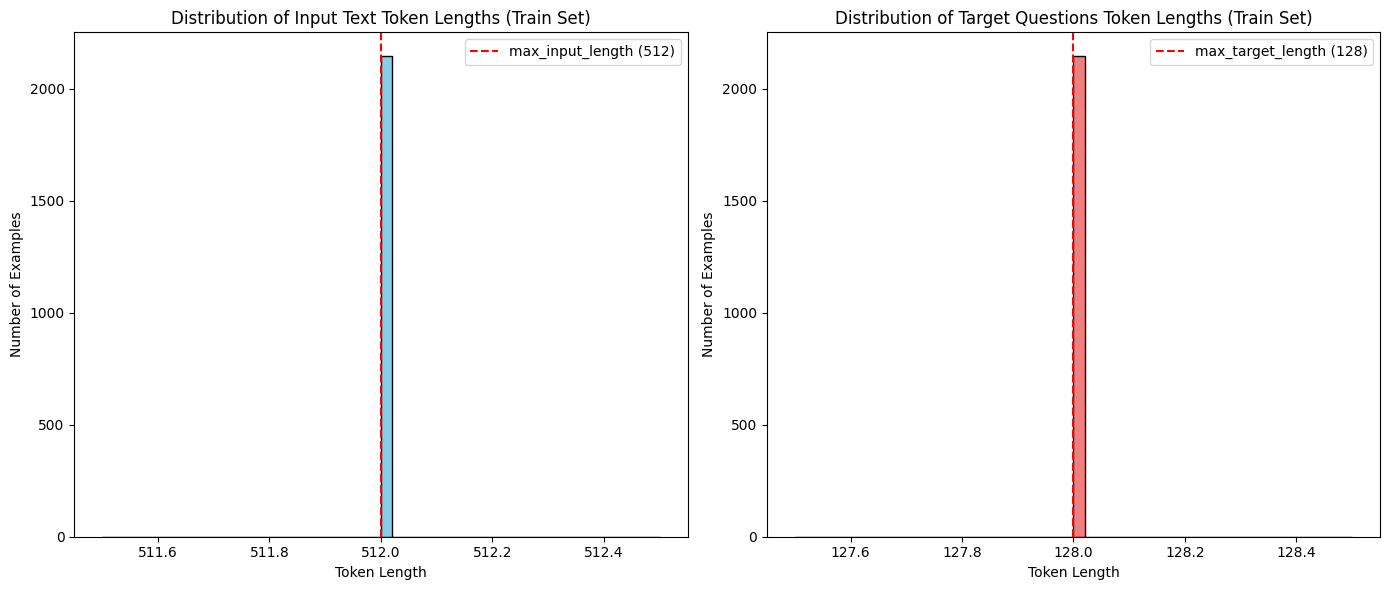

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from datasets import Dataset, DatasetDict # Import necessary for DatasetDict if not already imported
from transformers import AutoTokenizer # Import necessary if not already imported

# Assuming hf_dataset, tokenizer are available from previous cells

# 5. Preprocess the dataset for tokenization (Moved from cell EZgL8cCK7eFC)
max_input_length = 512 # Maximum length for resume_text + job_text input
max_target_length = 128 # Maximum length for concatenated questions target

def preprocess_function(examples):
    inputs = [ex for ex in examples['input_text']]
    targets = [ex for ex in examples['target_questions']]

    model_inputs = tokenizer(inputs, max_length=max_input_length, truncation=True)
    labels = tokenizer(targets, max_length=max_target_length, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Assuming df_finetune is available from previous steps
# It's important to list all original columns that are not 'input_ids', 'attention_mask', 'labels' or specific to HF Dataset.
# If df_finetune is not needed for further steps, and it was used to create hf_dataset, we can use hf_dataset.column_names for removal
# For robustness, let's assume df_finetune columns might be different from hf_dataset features
# We'll use the original hf_dataset[train].column_names to determine what to remove, plus '__index__'

# Get columns from a sample of the hf_dataset's 'train' split
# Ensure we only remove columns that are actually present in the dataset after .map
columns_to_remove = list(hf_dataset['train'].features.keys())
if '__index__' in columns_to_remove: # Remove if it was added by from_pandas
    columns_to_remove.remove('__index__')

tokenized_datasets = hf_dataset.map(preprocess_function, batched=True, remove_columns=columns_to_remove, load_from_cache_file=False)

print("\nSample of tokenized train dataset features:")
print(tokenized_datasets['train'][0])


# Now, proceed with the analysis of token lengths
print("\n--- Starting Token Length Analysis ---")

# Extract token lengths for input_text and target_questions
input_lengths = [len(x) for x in tokenized_datasets['train']['input_ids']]
# Labels are the tokenized input_ids for the target sequences
target_lengths = [len(x) for x in tokenized_datasets['train']['labels']]

print("\n--- Input Text Token Length Analysis ---")
print(f"Min input length: {np.min(input_lengths)}")
print(f"Max input length: {np.max(input_lengths)}")
print(f"Mean input length: {np.mean(input_lengths):.2f}")
print(f"Median input length: {np.median(input_lengths)}")
# Count examples truncated by max_input_length
truncated_inputs = sum(1 for length in input_lengths if length > max_input_length)
print(f"Number of input examples truncated (>{max_input_length}): {truncated_inputs} out of {len(input_lengths)} ({truncated_inputs/len(input_lengths)*100:.2f}%) ")

print("\n--- Target Questions Token Length Analysis ---")
print(f"Min target length: {np.min(target_lengths)}")
print(f"Max target length: {np.max(target_lengths)}")
print(f"Mean target length: {np.mean(target_lengths):.2f}")
print(f"Median target length: {np.median(target_lengths)}")
# Count examples truncated by max_target_length
truncated_targets = sum(1 for length in target_lengths if length > max_target_length)
print(f"Number of target examples truncated (>{max_target_length}): {truncated_targets} out of {len(target_lengths)} ({truncated_targets/len(target_lengths)*100:.2f}%) ")

# Plotting histograms for better visualization
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.hist(input_lengths, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribution of Input Text Token Lengths (Train Set)')
plt.xlabel('Token Length')
plt.ylabel('Number of Examples')
plt.axvline(x=max_input_length, color='r', linestyle='--', label=f'max_input_length ({max_input_length})')
plt.legend()

plt.subplot(1, 2, 2)
plt.hist(target_lengths, bins=50, color='lightcoral', edgecolor='black')
plt.title('Distribution of Target Questions Token Lengths (Train Set)')
plt.xlabel('Token Length')
plt.ylabel('Number of Examples')
plt.axvline(x=max_target_length, color='r', linestyle='--', label=f'max_target_length ({max_target_length})')
plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# 5. Preprocess the dataset for tokenization
max_input_length = 512 # Maximum length for resume_text + job_text input
max_target_length = 128 # Maximum length for concatenated questions target

def preprocess_function(examples):
    inputs = [ex for ex in examples['input_text']]
    targets = [ex for ex in examples['target_questions']]

    model_inputs = tokenizer(inputs, max_length=max_input_length, truncation=True)
    labels = tokenizer(targets, max_length=max_target_length, truncation=True)

    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Apply preprocessing. Dynamically determine columns to remove.
# Get original columns from the 'train' split of the hf_dataset
columns_to_remove = list(hf_dataset['train'].features.keys())

# Remove '__index__' only if it actually exists in the dataset's features
# It might not exist if Dataset.from_pandas was called with preserve_index=False
if '__index__' in columns_to_remove:
    columns_to_remove.remove('__index__')

tokenized_datasets = hf_dataset.map(preprocess_function, batched=True, remove_columns=columns_to_remove, load_from_cache_file=False)

print("\nSample of tokenized train dataset features:")
print(tokenized_datasets['train'][0])

Map:   0%|          | 0/2145 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]


Sample of tokenized train dataset features:
{'input_ids': [3806, 6813, 1693, 746, 10, 7934, 25000, 23936, 31864, 3, 23182, 9730, 3316, 3, 21342, 14151, 20698, 2035, 204, 203, 13, 3334, 771, 11, 3472, 351, 16, 220, 308, 8731, 53, 11, 6246, 1642, 209, 215, 13, 1780, 18, 106, 351, 16, 3, 6392, 188, 6, 16059, 10582, 6, 1174, 935, 1950, 8731, 53, 11, 472, 6049, 3, 87, 13967, 3113, 10582, 10178, 16, 6246, 1642, 3, 87, 10582, 6, 5623, 3, 27501, 9, 2532, 7, 11, 3, 5618, 18943, 2200, 15, 26, 16, 8, 4120, 13, 205, 13916, 11, 1642, 13, 7862, 9900, 31529, 7, 3037, 29, 2009, 351, 38, 18192, 11597, 1548, 3, 12279, 4751, 28, 3, 9, 2987, 12, 28144, 11, 1172, 821, 3, 87, 463, 16388, 7, 220, 308, 8731, 53, 6, 6246, 1642, 6, 3, 30578, 10582, 6, 1642, 13, 1881, 4267, 4128, 16059, 1693, 6, 472, 11783, 17, 9709, 1693, 3, 18, 7953, 7, 2260, 6, 16015, 7, 6, 3188, 7980, 3282, 1693, 41, 6392, 188, 201, 7862, 9900, 6, 6429, 6, 309, 17058, 6, 6157, 4369, 6, 10176, 77, 53, 6, 19193, 4300, 19559, 2263, 7, 18, 106,

In [ ]:
import transformers

# 6. Define Training Arguments
training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_finetuned",
    logging_strategy="epoch", # Changed from evaluation_strategy to logging_strategy
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    weight_decay=0.01,
    save_total_limit=3,
    num_train_epochs=30, # Adjusted to 30 epochs as requested
    predict_with_generate=True, # Needed for sequence-to-sequence tasks
    fp16=True, # Enable if your GPU supports it for faster training
    push_to_hub=False, # Set to True if you want to push to Hugging Face Hub
    report_to="none", # Disable reporting to W&B or other services by default
    logging_dir='./logs', # Reverted to logging_dir as TENSORBOARD_LOGGING_DIR caused a TypeError
    logging_steps=100,
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [ ]:
# 7. Initialize Data Collator and Trainer
data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator
)

print("DataCollator and Trainer initialized.")

DataCollator and Trainer initialized.


In [ ]:
# 9. Start Fine-tuning
print("\nStarting T5-FLAN fine-tuning...")
trainer.train()

print("\nFine-tuning complete. Model and tokenizer saved to ./flan_t5_finetuned")

# Optional: Save the fine-tuned model and tokenizer separately
trainer.save_model("./flan_t5_finetuned")
tokenizer.save_pretrained("./flan_t5_finetuned")

# Optional: Evaluate the model
print("\nEvaluating the fine-tuned model on the validation set...")
results = trainer.evaluate()
print(results)



Starting T5-FLAN fine-tuning...


Step,Training Loss
269,0.000000
538,0.000000
807,0.000000
1076,0.000000
1345,0.000000
1614,0.000000
1883,0.000000
2152,0.000000
2421,0.000000
2690,0.000000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...


Fine-tuning complete. Model and tokenizer saved to ./flan_t5_finetuned


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


Evaluating the fine-tuned model on the validation set...


Training Loss,Validation Loss,Step
0.000000,nan,8070


{'eval_loss': nan}


In [ ]:
#- torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM # Import AutoTokenizer and AutoModelForSeq2SeqLM

# Load the fine-tuned model and tokenizer
model_path = "./flan_t5_finetuned"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

# --- Test with new JD and Resume ---

def generate_questions(resume_text, jd_text, tokenizer, model, max_length=512, min_length=60): # Increased max_length and added min_length
    # Prepare the input text in the format expected by the model
    input_text = f"generate gap analysis questions: {resume_text} {jd_text}"

    # Tokenize the input
    input_ids = tokenizer.encode(input_text, return_tensors='pt', truncation=True, max_length=512)

    # Move input_ids to the same device as the model
    if torch.cuda.is_available():
        input_ids = input_ids.cuda()
        model.cuda()

    # Generate questions
    output_ids = model.generate(
        input_ids,
        max_length=max_length,
        min_length=min_length, # Added min_length to force longer output
        num_beams=4, # You can adjust this for better quality but slower generation
        early_stopping=False, # Changed to False to allow generation up to max_length
        no_repeat_ngram_size=3, # Added to prevent repetitive phrases
        repetition_penalty=1.5 # Added to penalize repetition of tokens
    )

    # Decode the generated questions
    generated_questions = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    return generated_questions

# Example usage:
new_resume_text = """
EXPERIENCE
Software Engineer | Tech Solutions Inc. | Jan 2020 - Present
- Developed and maintained web applications using Python, Django, and React.
- Implemented RESTful APIs, improving data retrieval efficiency by 30%.
- Collaborated with cross-functional teams to define, design, and ship new features.
Machine Learning Intern | AI Innovations Lab | May 2019 - Aug 2019
- Researched and developed NLP models for sentiment analysis.
- Preprocessed large datasets (1M+ entries) and performed feature engineering.
EDUCATION
Master of Science in Computer Science | State University | 2019
Bachelor of Engineering in Computer Science | City College | 2017
SKILLS
Programming: Python, Java, JavaScript, C++
Frameworks: Django, React, Flask, Node.js
Databases: PostgreSQL, MySQL, MongoDB
Tools: Docker, Git, AWS
Languages: English (Native), Spanish (Fluent)
"""

new_jd_text = """
Job Title: Senior Software Engineer
Company: Global Dynamics
Location: Remote

Responsibilities:
- Lead the design, development, and deployment of scalable backend services.
- Mentor junior engineers and conduct code reviews.
- Work with product managers to translate requirements into technical specifications.
- Optimize application performance and ensure high availability.

Requirements:
- 5+ years of experience in software development, with a focus on backend.
- Strong proficiency in Python and cloud platforms (AWS, Azure, GCP).
- Experience with microservices architecture and distributed systems.
- Excellent communication and leadership skills.
- Bachelor's or Master's degree in Computer Science or related field.
"""

print("Generating questions based on the provided JD and Resume...")
questions = generate_questions(new_resume_text, new_jd_text, tokenizer, model)

print("\n--- Generated Questions ---")
# For initial analysis, print the raw output to see how the model generates multiple questions.
# If individual questions are desired, a more robust parsing mechanism based on delimiters
# or specific model training will be needed. The current simple split might misinterpret output.
print(questions)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Generating questions based on the provided JD and Resume...

--- Generated Questions ---
What are the skills required to be a Senior Software Engineer at Global Dynamics? Select from the following. (A) Python, Django, and React; (B) Java, JavaScript, C++; (C) C++ frameworks; (D) PostgreSQL, MySQL, MongoDB; (E) Docker, Git, AWS; (F) Languages: English (Native), Spanish (Fluent)


Improvised model

In [ ]:
# =========================================================
# FIXED PIPELINE — CV/JD Gap-Analysis Question Generator
# Drop these cells in to replace your existing ones.
# =========================================================

import re
import pandas as pd
from sklearn.model_selection import train_test_split
from datasets import Dataset, DatasetDict
from transformers import (
    AutoTokenizer, AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments, Seq2SeqTrainer,
    DataCollatorForSeq2Seq, EarlyStoppingCallback
)

In [ ]:
# ---------------------------------------------------------
# 1. LOAD
# ---------------------------------------------------------
excel_file_path = '/content/cv_jd_gap_analysis_master.xlsx'
df = pd.read_excel(excel_file_path)
df.rename(columns={
    'Resume_Text': 'resume_text',
    'JD_Text': 'job_text',
    'Job_Title': 'job_title',
    'Gap_Analysis': 'gap_analysis',
}, inplace=True)


In [ ]:
# ---------------------------------------------------------
# 2. BUILD INPUT — gap analysis FIRST (most important signal),
#    then job title, then trimmed resume/JD.
#    This is the single biggest lever for question quality.
# ---------------------------------------------------------
MAX_RESUME_CHARS = 1200   # ~ a few hundred tokens, keep the top of the resume
MAX_JD_CHARS = 1200

def trim(text, n):
    text = '' if pd.isna(text) else str(text)
    return text[:n]

df['input_text'] = (
    "generate 5 interview questions from this gap analysis.\n"
    "Role: " + df['job_title'].fillna('') + "\n"
    "Gap Analysis: " + df['gap_analysis'].fillna('') + "\n"
    "Resume: " + df['resume_text'].apply(lambda t: trim(t, MAX_RESUME_CHARS)) + "\n"
    "Job Description: " + df['job_text'].apply(lambda t: trim(t, MAX_JD_CHARS))
)

In [ ]:
# ---------------------------------------------------------
# 3. BUILD TARGET — numbered, delimited, so the model learns
#    structure AND you can reliably parse it back out later.
# ---------------------------------------------------------
question_columns = ['Question_1', 'Question_2', 'Question_3', 'Question_4', 'Question_5']
for col in question_columns:
    df[col] = df[col].fillna('').astype(str).str.strip()

df['target_questions'] = df.apply(
    lambda r: "\n".join(f"{i+1}) {r[c]}" for i, c in enumerate(question_columns)),
    axis=1
)

# Sanity check target length so you set max_target_length correctly
target_token_lens = df['target_questions'].str.split().str.len()
print("Target word-count percentiles:\n", target_token_lens.describe())
# -> set max_target_length a bit above the 95th percentile, in TOKENS not words
# flan-t5 tokenizer inflates word count by ~1.3x typically; check directly:


Target word-count percentiles:
 count    2384.000000
mean      156.469379
std         9.979916
min       126.000000
25%       150.000000
50%       156.000000
75%       163.000000
max       203.000000
Name: target_questions, dtype: float64


In [ ]:
# ---------------------------------------------------------
# 4. STRATIFIED SPLIT — keep every job_title represented in
#    both train and validation.
# ---------------------------------------------------------
train_df, val_df = train_test_split(
    df, test_size=0.1, random_state=42, stratify=df['job_title']
)

hf_dataset = DatasetDict({
    'train': Dataset.from_pandas(train_df, preserve_index=False),
    'validation': Dataset.from_pandas(val_df, preserve_index=False),
})



In [ ]:
# ---------------------------------------------------------
# 5. TOKENIZE
# ---------------------------------------------------------
model_name = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Check actual token length before picking max_input_length
sample_input_lens = [len(tokenizer(t)['input_ids']) for t in df['input_text'].sample(200, random_state=0)]
sample_target_lens = [len(tokenizer(t)['input_ids']) for t in df['target_questions'].sample(200, random_state=0)]
print("input_text token length p95:", sorted(sample_input_lens)[int(len(sample_input_lens)*0.95)])
print("target token length p95:", sorted(sample_target_lens)[int(len(sample_target_lens)*0.95)])

max_input_length = 640   # raise from 512 — gap_analysis + trimmed resume/JD needs room
max_target_length = 220  # raise from 128 — 5 questions need more than 128 tokens

def preprocess_function(examples):
    model_inputs = tokenizer(examples['input_text'], max_length=max_input_length, truncation=True)
    labels = tokenizer(examples['target_questions'], max_length=max_target_length, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

columns_to_remove = list(hf_dataset['train'].features.keys())
tokenized_datasets = hf_dataset.map(preprocess_function, batched=True, remove_columns=columns_to_remove)


Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (654 > 512). Running this sequence through the model will result in indexing errors


input_text token length p95: 713
target token length p95: 251


Map:   0%|          | 0/2145 [00:00<?, ? examples/s]

Map:   0%|          | 0/239 [00:00<?, ? examples/s]

In [ ]:
# ---------------------------------------------------------
# 5b. CLEAR STALE GPU MEMORY — do this every time before
#     building/training a model in a Colab session.
# ---------------------------------------------------------
import gc, torch
for _name in ["model", "trainer"]:
    if _name in globals():
        del globals()[_name]
gc.collect()
torch.cuda.empty_cache()
print(torch.cuda.memory_summary(abbreviated=True))

# Model reloading and freezing logic has been moved to cell 44441e88.

|===========================================================================|
|                  PyTorch CUDA memory summary, device ID 0                 |
|---------------------------------------------------------------------------|
|            CUDA OOMs: 0            |        cudaMalloc retries: 0         |
|===========================================================================|
|        Metric         | Cur Usage  | Peak Usage | Tot Alloc  | Tot Freed  |
|---------------------------------------------------------------------------|
| Allocated memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Active memory         |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------------------|
| Requested memory      |      0 B   |      0 B   |      0 B   |      0 B   |
|---------------------------------------------------------------

In [ ]:
# ---------------------------------------------------------
# 6. TRAINING ARGS — fp16 OFF (T5 is known to NaN under fp16).
#    T4 GPUs don't support bf16 in hardware, so instead of fp16
#    we shrink the per-step memory footprint: smaller micro-batch
#    + gradient accumulation (keeps the *effective* batch size the
#    same) + gradient checkpointing (trades compute for memory).
# ---------------------------------------------------------
training_args = Seq2SeqTrainingArguments(
    output_dir="./flan_t5_finetuned",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=3e-4,
    per_device_train_batch_size=2,       # down from 8
    per_device_eval_batch_size=2,
    gradient_accumulation_steps=4,       # 2*4 = effective batch size 8
    gradient_checkpointing=True,         # big memory saver, ~small speed cost
    weight_decay=0.01,
    save_total_limit=2,
    num_train_epochs=15,
    predict_with_generate=True,
    fp16=False,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
)

data_collator = DataCollatorForSeq2Seq(tokenizer, model=model)

trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    data_collator=data_collator,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=3)],
)

trainer.train()
trainer.save_model("./flan_t5_finetuned")
tokenizer.save_pretrained("./flan_t5_finetuned")
print(trainer.evaluate())


Epoch,Training Loss,Validation Loss
1,1.565047,0.224756
2,0.889142,0.192033
3,0.712641,0.173441
4,0.607529,0.169558
5,0.538755,0.168240
6,0.485176,0.168046
7,0.444716,0.169506
8,0.412324,0.169822
9,0.379711,0.174534


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight'].


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch
0.379711,0.168046,9


{'eval_loss': 0.16804644465446472}


In [ ]:
# ---------------------------------------------------------
# 7. INFERENCE — matching input format, with parsing back
#    into 5 discrete questions.
# ---------------------------------------------------------
def generate_questions(job_title, gap_analysis, resume_text, jd_text, tokenizer, model,
                        max_length=220):
    input_text = (
        "generate 5 interview questions from this gap analysis.\n"
        f"Role: {job_title}\n"
        f"Gap Analysis: {gap_analysis}\n"
        f"Resume: {trim(resume_text, MAX_RESUME_CHARS)}\n"
        f"Job Description: {trim(jd_text, MAX_JD_CHARS)}"
    )
    input_ids = tokenizer.encode(input_text, return_tensors='pt', truncation=True, max_length=max_input_length)
    if torch.cuda.is_available():
        input_ids = input_ids.cuda()
        model.cuda()
    output_ids = model.generate(
        input_ids,
        max_length=max_length,
        num_beams=4,
        no_repeat_ngram_size=3,
    )
    raw = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    # parse "1) ... 2) ... " back into a list
    parts = re.split(r'\n?\d\)\s*', raw)
    questions = [p.strip() for p in parts if p.strip()]
    return questions


### Test the Fine-Tuned Model

Now, let's use the `generate_questions` function to see how our fine-tuned model performs with new, unseen data. We'll provide a sample resume, job description, job title, and a gap analysis to generate interview questions.

In [ ]:
import torch

# Example data for inference
example_job_title = "Software Engineer"
example_gap_analysis = "Candidate lacks experience with distributed systems and cloud platforms (AWS, Azure, GCP), which are key requirements for the role. The resume highlights experience with Django and React, but the job requires a backend focus."
example_resume_text = """
EXPERIENCE
Software Engineer | Tech Solutions Inc. | Jan 2020 - Present
- Developed and maintained web applications using Python, Django, and React.
- Implemented RESTful APIs, improving data retrieval efficiency by 30%.
- Collaborated with cross-functional teams to define, design, and ship new features.
Machine Learning Intern | AI Innovations Lab | May 2019 - Aug 2019
- Researched and developed NLP models for sentiment analysis.
- Preprocessed large datasets (1M+ entries) and performed feature engineering.
EDUCATION
Master of Science in Computer Science | State University | 2019
Bachelor of Engineering in Computer Science | City College | 2017
SKILLS
Programming: Python, Java, JavaScript, C++
Frameworks: Django, React, Flask, Node.js
Databases: PostgreSQL, MySQL, MongoDB
Tools: Docker, Git, AWS
Languages: English (Native), Spanish (Fluent)
"""
example_jd_text = """
Job Title: Senior Software Engineer
Company: Global Dynamics
Location: Remote

Responsibilities:
- Lead the design, development, and deployment of scalable backend services.
- Mentor junior engineers and conduct code reviews.
- Work with product managers to translate requirements into technical specifications.
- Optimize application performance and ensure high availability.

Requirements:
- 5+ years of experience in software development, with a focus on backend.
- Strong proficiency in Python and cloud platforms (AWS, Azure, GCP).
- Experience with microservices architecture and distributed systems.
- Excellent communication and leadership skills.
- Bachelor's or Master's degree in Computer Science or related field.
"""

print("Generating questions based on the example data...")

# Use the generate_questions function defined in the previous cell
# Make sure `MAX_RESUME_CHARS`, `MAX_JD_CHARS`, `max_input_length` and `trim` are defined in previously executed cells.
# (They are defined in `mkkxLyH54RrQ` and `0yYQFTaw4dAo`)
generated_interview_questions = generate_questions(
    job_title=example_job_title,
    gap_analysis=example_gap_analysis,
    resume_text=example_resume_text,
    jd_text=example_jd_text,
    tokenizer=tokenizer,
    model=model
)

print("\n--- Generated Interview Questions ---")
for i, q in enumerate(generated_interview_questions):
    print(f"{i+1}) {q}")

Generating questions based on the example data...

--- Generated Interview Questions ---
1) This role requires experience with distributed systems and cloud platforms (AWS, Azure, GCP). What's the closest experience you've had to this, even if it wasn't the main focus of a job?
2) Can you tell me about any exposure to minimum 5+ years of experience in software development, with a focus on backend, since it isn't clear from what's listed?
3) Tell me about a time your experience with experience with Django, React, Flask, Node.js databases: PostgreSQL, MySQL, MongoDB Tools: Docker, Git, AWS Languages: English (Native), Spanish (Fluent) I don't see communication and leadership skills preferred for this position.


### Another Example to Test the Fine-Tuned Model

Let's try with a different set of inputs to observe the model's generalization capabilities.

In [ ]:
# Another example data for inference
example_job_title_2 = "Data Scientist"
example_gap_analysis_2 = "Candidate has strong theoretical knowledge in machine learning but lacks practical experience in deploying models to production and A/B testing. Resume focuses heavily on academic projects."
example_resume_text_2 = """
EXPERIENCE
Research Assistant | University of Data Science | Jan 2021 - Present
- Conducted research on novel deep learning architectures for natural language processing.
- Implemented models using TensorFlow and PyTorch, achieving state-of-the-art results on benchmark datasets.
- Published 3 papers in peer-reviewed conferences.
EDUCATION
Ph.D. in Computer Science | University of Data Science | 2023 (Expected)
Master of Science in Data Science | Data Institute | 2020
SKILLS
Programming: Python (NumPy, Pandas, Scikit-learn, TensorFlow, PyTorch), R
Tools: Jupyter, Git, Docker
Concepts: Machine Learning, Deep Learning, NLP, Computer Vision, Statistical Modeling
"""
example_jd_text_2 = """
Job Title: Senior Data Scientist
Company: DataDriven Solutions
Location: New York

Responsibilities:
- Develop, deploy, and maintain machine learning models in a production environment.
- Design and execute A/B tests to evaluate model performance and impact.
- Collaborate with engineering and product teams to integrate models into existing systems.
- Mentor junior data scientists.

Requirements:
- 3+ years of industry experience in data science, with a focus on model deployment.
- Strong programming skills in Python.
- Experience with cloud platforms (AWS, Azure, GCP) and MLOps practices.
- Solid understanding of statistical inference and experimental design (A/B testing).
- Ph.D. or Master's degree in a quantitative field.
"""

print("Generating questions based on the second example data...")

generated_interview_questions_2 = generate_questions(
    job_title=example_job_title_2,
    gap_analysis=example_gap_analysis_2,
    resume_text=example_resume_text_2,
    jd_text=example_jd_text_2,
    tokenizer=tokenizer,
    model=model
)

print("\n--- Generated Interview Questions (Example 2) ---")
for i, q in enumerate(generated_interview_questions_2):
    print(f"{i+1}) {q}")

Generating questions based on the second example data...

--- Generated Interview Questions (Example 2) ---
1) This role requires understanding of statistical inference and experimental design (A/B testing). What's the closest experience you've had to this, even if it wasn't the main focus of a job?
2) Can you tell me about any exposure to with cloud platforms (AWS, Azure, GCP) and MLOps practices, since it isn't clear from what's listed?
3) Your resume lists 'Microsoft Visual Studio 2012' as a skill — what'll you do differently now?
4) Tell me about a time your experience with experience with Jupyter, Git, Docker concepts: Machine Learning, Deep Learning, NLP, Computer Vision, Statistical Modeling


### Save the Fine-Tuned Model to Disk

To save your fine-tuned model and its corresponding tokenizer, you can use the `trainer.save_model()` and `tokenizer.save_pretrained()` methods. This will create a directory containing the model weights, configuration, and tokenizer files.

In [ ]:
# Define the path where you want to save the model
output_dir = "./flan_t5_finetuned_local_save"

# Save the model
trainer.save_model(output_dir)

# Save the tokenizer
tokenizer.save_pretrained(output_dir)

print(f"Model and tokenizer saved to: {output_dir}")
print("You can now download this folder from the Colab file browser sidebar (left panel) to your local system.")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model and tokenizer saved to: ./flan_t5_finetuned_local_save
You can now download this folder from the Colab file browser sidebar (left panel) to your local system.


### Zip the Model Folder for Easy Download

Since you're encountering issues with directly downloading the folder, we can compress it into a `.zip` file using Python's `zipfile` module. This will create a single archive that you can then download.

In [ ]:
import zipfile
import os

# Define the directory to be zipped (where your model and tokenizer are saved)
folder_to_zip = './flan_t5_finetuned_local_save'

# Define the name for the output zip file
zip_file_name = './flan_t5_finetuned_local_save.zip'

print(f"Zipping folder: {folder_to_zip} into {zip_file_name}...")

# Create a ZipFile object
with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for root, dirs, files in os.walk(folder_to_zip):
        for file in files:
            # Construct the full path to the file
            file_path = os.path.join(root, file)
            # Add the file to the zip archive, preserving its relative path within the folder
            zipf.write(file_path, os.path.relpath(file_path, folder_to_zip))

print(f"Successfully created {zip_file_name}")
print("Now you should see 'flan_t5_finetuned_local_save.zip' in the Colab file browser. You can download this single zip file.")

Zipping folder: ./flan_t5_finetuned_local_save into ./flan_t5_finetuned_local_save.zip...
Successfully created ./flan_t5_finetuned_local_save.zip
Now you should see 'flan_t5_finetuned_local_save.zip' in the Colab file browser. You can download this single zip file.
